In [45]:
search_embedding = '/data0/teja_codes/ImmersoAiResearch/ImageMatchingAlgo/image_search/place_search/place_clip_embeddings/South_India/Andhra_Pradesh/Araku_Valley/image_5.npy'
search_image = '/data0/indic_data/images/places/South_India/Andhra_Pradesh/Rajahmundry/image_5.jpg'

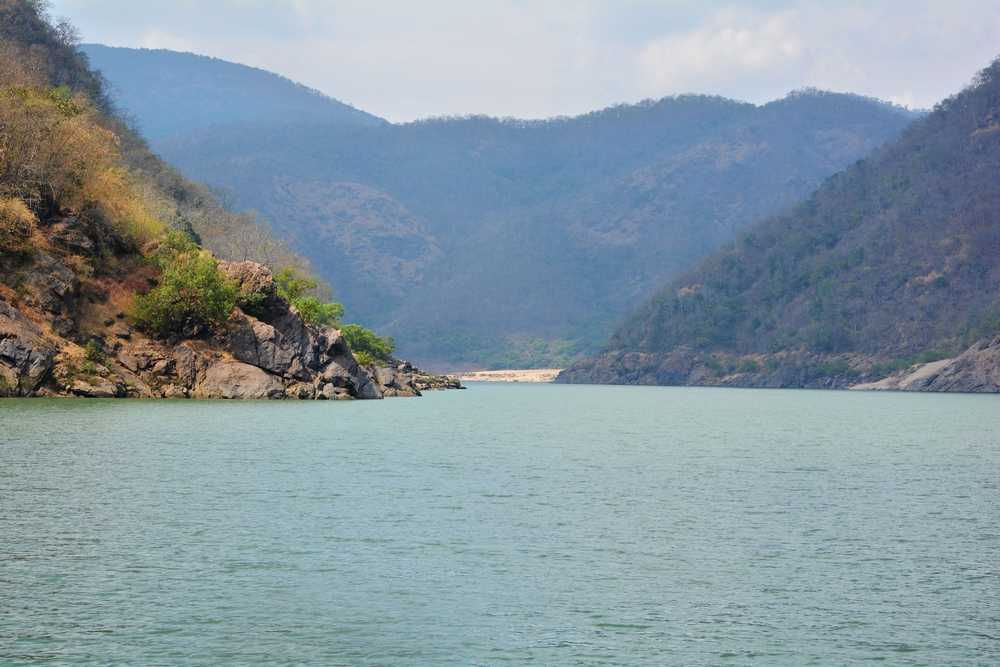

In [56]:
# show the image 
from PIL import Image   
import os

search_image = '/data0/indic_data/images/places/South_India/Andhra_Pradesh/Rajahmundry/image_6.jpg'
img = Image.open(search_image)
img.show()

In [47]:
all_embeddings = []

import numpy as np
emd_path = '/data0/teja_dataset_embeddings/clip_embeddings'
embedding_paths = [os.path.join(emd_path, f) for f in os.listdir(emd_path) if f.endswith('.npy')]


#shuffle the embedding paths
import random
random.shuffle(embedding_paths)

from tqdm import tqdm

#load the embeddings
for emb in tqdm(embedding_paths[:500]):
    embedding = np.load(emb)
    all_embeddings.append(embedding)

all_embeddings = np.array(all_embeddings)
all_embeddings = all_embeddings.reshape(500, 768)
print("total embeddings loaded", all_embeddings.shape)

100%|██████████| 500/500 [00:00<00:00, 5351.61it/s]

total embeddings loaded (500, 768)


In [48]:
# check using cosine similarity
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

query_embedding = np.load('/data0/teja_codes/ImmersoAiResearch/ImageMatchingAlgo/image_search/place_search/place_clip_embeddings/South_India/Andhra_Pradesh/Araku_Valley/image_5.npy')

similarities = cosine_similarity(query_embedding, all_embeddings)

In [49]:
# get me the index of the embedding with similarty > 0.8
indices = np.where(similarities > 0.5)[1]
indices

array([ 63,  94, 169, 231, 286, 288, 450, 466])

In [50]:
# the images are located at /data0/sriprabha/codes/SimpleTuner/datasets/eros_10lakh/train
image_path = '/data0/sriprabha/codes/SimpleTuner/datasets/eros_10lakh/train'

# the images with jpg image from the embedding_paths[:500]
image_paths = [os.path.join(image_path, os.path.basename(f).replace('.npy', '.png')) for f in embedding_paths[:500]]

In [54]:
# !pip install fiftyone
# get the imges in the indices
filtered_indices = np.where(similarities > 0.5)[1]
img_filtered_paths = [image_paths[i] for i in filtered_indices]

In [55]:
import fiftyone as fo

# Create a dataset from a list of images
dataset = fo.Dataset.from_images(
    image_paths,
)

session = fo.launch_app(dataset)

 100% |█████████████████| 500/500 [84.1ms elapsed, 0s remaining, 5.9K samples/s]   


In [53]:
session

Dataset:          2025.07.22.13.48.42.951082
Media type:       image
Num samples:      500
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/